# CP8305 Final Project
## Notebook 3 – Modeling (Diabetes 130-US Hospitals)

### Objectives
- Load the processed Diabetes 130-US dataset.
- Train and compare a comprehensive set of classifiers via leakage-safe k-fold stratified CV (fold count: `K_FOLDS` in Setup).
- Evaluate with AUC-ROC, AUPRC, F1, Cohen's Kappa, 95% CIs, and statistical significance tests.
- Conduct cost-sensitive threshold tuning aligned to HRRP readmission penalties.
- Produce SHAP, permutation importance, and PDP explainability artifacts.
- Export human-readable rules from tree-based models.

#### The methods we are using
* group-k-fold cross validation with confidence interval
-- we need group-k-fold to avoid data leakage since we have multiple encounters for the same patient.
* Kappa Statistic

#### Models

**Baselines:** ZeroR (majority class), OneR (single-split decision stump)

**Interpretable:** Gaussian Naive Bayes, Logistic Regression, SGDClassifier (log loss), Decision Tree (CART), kNN

**Ensemble:** Random Forest, Gradient Boosting, XGBoost, LightGBM

**Explainability:** SHAP, LIME, Permutation Importance, Partial Dependence Plots, Decision Rule Export


#### Metrics
* Accuracy & Balanced Accuracy
* Precision, Recall, F1, Weighted F1
* AUC-ROC, AUPRC (critical for imbalanced data)
* Cohen's Kappa (chance-corrected agreement)
* Precision@K and Recall@K (top-5%, top-10% operational capacity)
* Brier Score (calibration quality)
* 95% Confidence Intervals from fold distributions
* Paired t-test and Wilcoxon signed-rank significance tests

#### Evaluation Approach
All experiments use **stratified group k-fold cross-validation** (`K_FOLDS` folds, set in Section 1) with group-aware splitting (via `patient_nbr`) to prevent data leakage from repeated encounters. Preprocessing (scaling, SMOTE) is applied **strictly within each training fold**. Hyperparameter tuning uses **nested CV** (inner 5-fold) to produce unbiased performance estimates.

## 1. Setup

In [1]:
%pip install -r /scratch/indrisch/CP8305FP/requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cross-validation: number of folds for all outer / standard stratified group CV in this notebook.
# Nested hyperparameter tuning keeps an inner 5-fold loop (run_tuned_cv_experiment(..., n_inner_splits=5)).
K_FOLDS = 5

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modeling import (
    split_data,
    get_stratified_cv,
    CLASSIFICATION_MODELS,
    CLASSIFICATION_MODELS_FAST,
    CLASSIFICATION_MODELS_ADVANCED,
    CLASSIFICATION_MODELS_SGD,
    HYPERPARAM_GRIDS,
    SCALE_SENSITIVE_MODELS,
    build_fold_pipeline,
    compute_classification_metrics,
    compute_topk_metrics,
    compute_confidence_interval,
    run_cv_experiment,
    build_metrics_summary_table,
    run_significance_tests,
    compute_calibration_diagnostics,
    calibrate_model,
    compute_expected_cost,
    sweep_thresholds_cost,
    DEFAULT_COST_MATRIX,
    compute_shap_values,
    export_tree_rules,
    export_forest_top_rules,
    run_tuned_cv_experiment,
    compare_imbalance_strategies,
    predict_positive_probability,
    tune_decision_threshold,
    select_features_l1,
    train_classifier,
    evaluate_classifier,
    save_model,
    SHAP_AVAILABLE,
    LIME_AVAILABLE,
)
from src.visualization import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_permutation_importance,
    plot_roc_curves,
    plot_pr_curves,
    plot_calibration_curves,
    plot_model_comparison,
    plot_confidence_intervals,
    plot_cost_threshold_sweep,
    plot_shap_summary,
    plot_pdp,
    save_figure,
)

np.random.seed(42)
sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Processed Data

In [4]:
DATA_FILE = Path('..') / 'data' / 'diabetes130' / 'processed' / 'processed_dataset.csv'
df = pd.read_csv(DATA_FILE)
print(f'Shape: {df.shape}')
df.head()

Shape: (69990, 2473)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary,age_ordinal,...,admission_type_group_other,admission_type_group_urgent,discharge_group_inpatient,discharge_group_left_ama,discharge_group_other,discharge_group_transfer,admission_source_group_newborn,admission_source_group_other,admission_source_group_referral,admission_source_group_transfer
0,13,68,2,28,0,0,0,8,0,9,...,False,True,False,False,False,False,False,False,False,True
1,12,33,3,18,0,0,0,8,0,10,...,False,False,False,False,False,True,False,False,False,True
2,1,51,0,8,0,0,0,5,0,5,...,False,False,False,False,False,False,False,False,False,False
3,9,47,2,17,0,0,0,9,0,5,...,False,False,False,False,False,False,False,False,False,False
4,3,31,6,16,0,0,0,9,0,6,...,False,True,False,False,False,False,False,False,True,False


## 3. Feature / Target Split

In [5]:
# Target column used in preprocessing notebook.
TARGET = 'readmitted_binary'

# Keep patient_nbr only for optional group-aware CV, never as a model feature.
group_ids = df['patient_nbr'].copy() if 'patient_nbr' in df.columns else None

drop_columns = [TARGET]
for leakage_col in ['encounter_id', 'patient_nbr']:
    if leakage_col in df.columns:
        drop_columns.append(leakage_col)

X = df.drop(columns=drop_columns)
y = df[TARGET]

print(f'Features: {X.shape[1]}  |  Target: {y.name}  |  Classes/Values: {y.nunique()}')
if group_ids is not None:
    print('Group-aware CV is enabled via patient_nbr (excluded from X).')
else:
    print('Group-aware CV unavailable (patient_nbr not present in processed data).')

Features: 2472  |  Target: readmitted_binary  |  Classes/Values: 2
Group-aware CV unavailable (patient_nbr not present in processed data).


In [6]:
# Split once up-front with stratification so class imbalance is preserved.
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=True,
 )

# If group IDs are available, keep the train-split groups for CV-only use.
groups_train = group_ids.loc[X_train.index] if group_ids is not None else None

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Positive class ratio (train): {y_train.mean():.4f}')
print(f'Positive class ratio (test) : {y_test.mean():.4f}')

Train: (55992, 2472)  |  Test: (13998, 2472)
Positive class ratio (train): 0.0898
Positive class ratio (test) : 0.0898


In [7]:
# Run L1-based feature selection on training data only to avoid leakage.
selected_columns, l1_selector_model = select_features_l1(X_train, y_train, C=0.1)

X_train_fs = X_train[selected_columns].copy()
X_test_fs = X_test[selected_columns].copy()

print(f'Selected features for optional reduced model: {len(selected_columns)}')

/home/indrisch/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 feature selection kept 2472 of 2472 features.
Selected features for optional reduced model: 2472


---
## 4. Classification – Unified CV Experiment
All candidate models are evaluated under identical fold-local pipelines (scaler → classifier) to ensure fair, leakage-free comparison across `K_FOLDS` stratified folds.

In [8]:
# Run k-fold stratified CV with fold-local pipelines for all registered models.
# Preprocessing (scaling) is fit strictly on training folds to prevent leakage.
# Class weighting + fold-local SMOTE address the ~9% minority class imbalance;
# a lower threshold (0.1) favours recall of the minority class.
experiment_results = run_cv_experiment(
    X_train, y_train,
    model_configs=CLASSIFICATION_MODELS,
    n_splits=K_FOLDS,
    groups=groups_train,
    scale=True,
    imbalance_strategy='class_weight+smote',
    threshold=0.1,
    random_state=42,
)


  Model: zero_r
  Fold  1: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  2: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  3: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  4: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  5: F1=0.0000  AUC=0.5000  Kappa=0.0000
            f1: 0.0000 [0.0000, 0.0000]
       auc_roc: 0.5000 [0.5000, 0.5000]
         kappa: 0.0000 [0.0000, 0.0000]

  Model: one_r
  Fold  1: F1=0.1649  AUC=0.5880  Kappa=0.0000
  Fold  2: F1=0.1649  AUC=0.5682  Kappa=0.0000
  Fold  3: F1=0.1647  AUC=0.5819  Kappa=0.0000
  Fold  4: F1=0.1647  AUC=0.5771  Kappa=0.0000
  Fold  5: F1=0.1649  AUC=0.5872  Kappa=0.0000
            f1: 0.1648 [0.1647, 0.1649]
       auc_roc: 0.5805 [0.5704, 0.5906]
         kappa: 0.0000 [0.0000, 0.0000]

  Model: naive_bayes
  Fold  1: F1=0.1669  AUC=0.5105  Kappa=0.0041
  Fold  2: F1=0.1669  AUC=0.5107  Kappa=0.0042
  Fold  3: F1=0.1668  AUC=0.5106  Kappa=0.0042
  Fold  4: F1=0.1670  AUC=0.5111  Kappa=0.0044
  Fold  5: F1=0.1666  AUC=0.5093  Kappa=0.0036


=== Model Comparison (sorted by F1, with 95% CIs) ===


,f1_mean,f1_std,f1_ci_lower,f1_ci_upper,auc_roc_mean,auc_roc_std,auc_roc_ci_lower,auc_roc_ci_upper,auprc_mean,auprc_std,...,kappa_ci_lower,kappa_ci_upper,brier_score_mean,brier_score_std,brier_score_ci_lower,brier_score_ci_upper,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
model,,,,,,,,,,,,,,,,,,,,,
random_forest,0.195239,0.003676,0.190675,0.199804,0.622342,0.005654,0.615322,0.629362,0.151322,0.006866,...,0.042422,0.052828,0.081513,0.000293,0.081150,0.081877,0.580728,0.007513,0.571400,0.590057
gradient_boosting,0.186177,0.001213,0.184670,0.187683,0.627939,0.008295,0.617639,0.638239,0.153603,0.006733,...,0.030659,0.034328,0.082202,0.000351,0.081766,0.082638,0.564968,0.002866,0.561410,0.568527
knn,0.173416,0.004961,0.167256,0.179575,0.547784,0.012098,0.532763,0.562805,0.101729,0.003165,...,0.014490,0.028754,0.257260,0.002427,0.254247,0.260273,0.536884,0.009939,0.524544,0.549225
sgd_classifier,0.169259,0.000860,0.168192,0.170327,0.586458,0.010435,0.573501,0.599416,0.126799,0.005507,...,0.007174,0.009612,0.238137,0.004069,0.233084,0.243190,0.519969,0.002336,0.517069,0.522870
logistic_regression,0.168662,0.000718,0.167770,0.169553,0.601037,0.008403,0.590604,0.611471,0.141021,0.008299,...,0.005924,0.007989,0.225384,0.001238,0.223847,0.226921,0.517141,0.002036,0.514613,0.519668
naive_bayes,0.166840,0.000156,0.166646,0.167034,0.510448,0.000662,0.509627,0.511270,0.091544,0.000094,...,0.003755,0.004434,0.830333,0.002293,0.827486,0.833180,0.510441,0.000680,0.509597,0.511285
xgboost,0.166715,0.001170,0.165262,0.168168,0.616506,0.007967,0.606614,0.626398,0.151718,0.004271,...,0.000921,0.004453,0.210507,0.002354,0.207585,0.213429,0.507318,0.003866,0.502518,0.512118
one_r,0.164798,0.000078,0.164702,0.164895,0.580500,0.008145,0.570387,0.590613,0.108255,0.002373,...,0.000000,0.000000,0.232844,0.000900,0.231726,0.233961,0.500000,0.000000,0.500000,0.500000
decision_tree,0.127512,0.014081,0.110029,0.144996,0.521941,0.007429,0.512717,0.531165,0.095310,0.002524,...,0.026046,0.065439,0.149879,0.004129,0.144751,0.155006,0.521941,0.007429,0.512717,0.531165



Best model by CV F1: random_forest
Figure saved to /scratch/indrisch/CP8305FP/reports/figures/03_f1_confidence_intervals.png


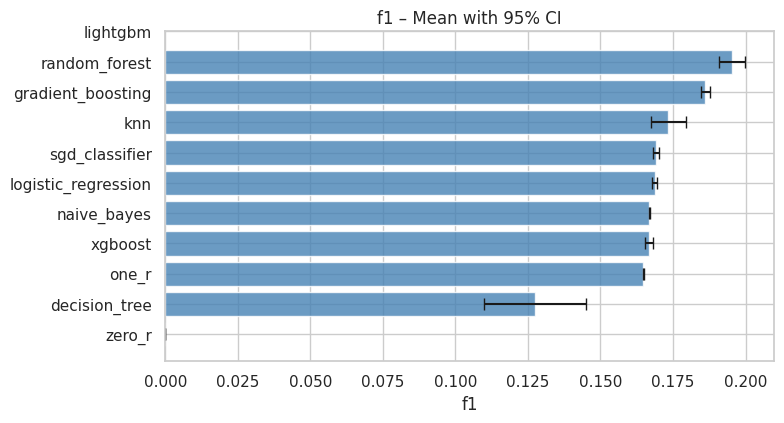

Figure saved to /scratch/indrisch/CP8305FP/reports/figures/03_model_comparison.png


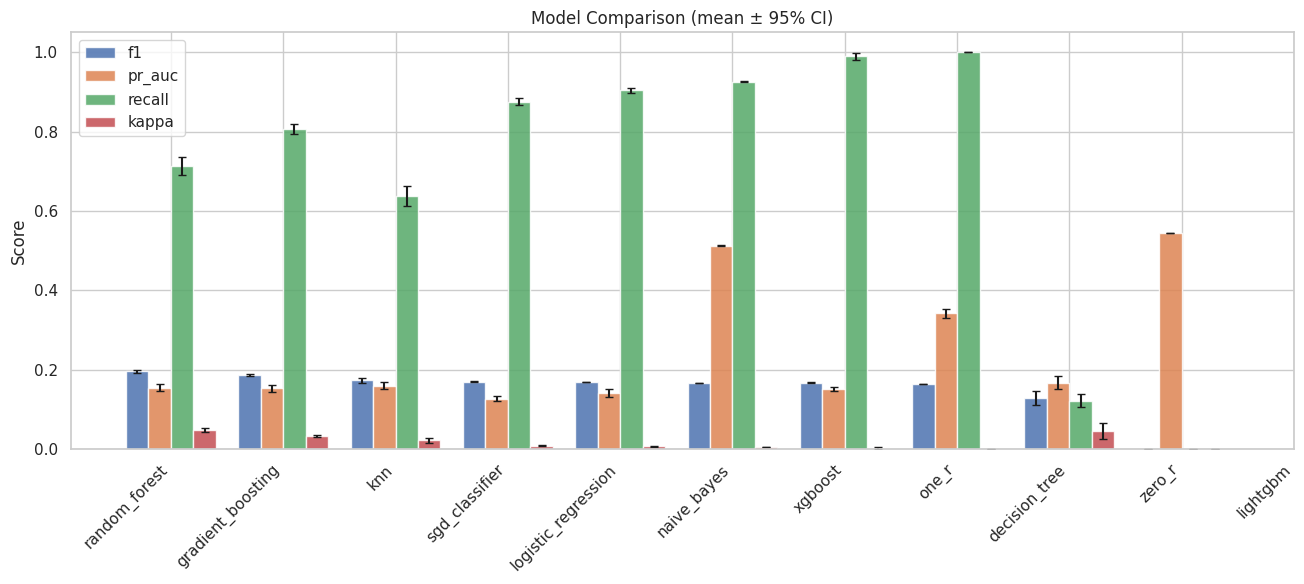

In [9]:
# Build the metrics summary table with 95% CIs from fold distributions.
summary_table = build_metrics_summary_table(experiment_results)
print('=== Model Comparison (sorted by F1, with 95% CIs) ===')
display(summary_table)

# Identify best model.
BEST_CLF = summary_table.index[0]
print(f'\nBest model by CV F1: {BEST_CLF}')

# Forest plot of F1 confidence intervals.
fig = plot_confidence_intervals(summary_table, metric='f1')
save_figure(fig, '03_f1_confidence_intervals.png')
plt.show()

# Grouped bar chart across key metrics.
fig = plot_model_comparison(summary_table, metrics=['f1', 'pr_auc', 'recall', 'kappa'])
save_figure(fig, '03_model_comparison.png')
plt.show()

---
## 4.5 SGDClassifier on reduced features (fold-local)

Training **SGDClassifier** on the full ~2.5k one-hot columns is possible but slow; here we compare three **fold-local** reductions first (fit on the training fold only, transform the validation fold—same leakage posture as scaling), then fit SGD on the reduced matrix.

**RFECV** at full dimension would require enormous numbers of model refits per fold. **SelectFromModel** with an ensemble is the practical substitute at this scale; if you need RFECV for a write-up, restrict it to a low-dimensional input (for example after PCA to 50 components) and use a large `step` to limit refits.

The next cell uses **lightweight defaults** for faster runs: **`K_FOLDS`-fold** CV (same as Section 4), **PCA** with 32 components, **SelectKBest** with `k=20`, and **SelectFromModel** capped with `max_features=20`, plus a smaller ensemble for the selector. Increase PCA / k / `max_features` if you need richer features.

In [10]:
from sklearn.base import clone

# Tree/boosting model for SelectFromModel: best mean F1 among advanced models in this CV run.
_advanced_in_run = [
    k for k in CLASSIFICATION_MODELS
    if k in experiment_results and k in CLASSIFICATION_MODELS
]
if _advanced_in_run:
    ref_tree_name = max(
        _advanced_in_run,
        key=lambda k: experiment_results[k]["aggregate"]["f1"]["mean"],
    )
else:
    ref_tree_name = next(
        k for k in ("lightgbm", "xgboost", "random_forest") if k in CLASSIFICATION_MODELS
    )

selector_base = clone(CLASSIFICATION_MODELS[ref_tree_name])
if hasattr(selector_base, "set_params"):
    if ref_tree_name == "lightgbm":
        selector_base.set_params(n_estimators=20, num_leaves=31, max_depth=5, verbose=-1)
    elif ref_tree_name == "xgboost":
        selector_base.set_params(n_estimators=20, max_depth=4, verbosity=0)
    elif ref_tree_name == "catboost":
        selector_base.set_params(iterations=20, depth=5, verbose=0)
    elif ref_tree_name in ("random_forest", "gradient_boosting"):
        selector_base.set_params(n_estimators=25)

print(
    f"SelectFromModel base estimator: {ref_tree_name} "
    "(lighter settings than full CV models for speed)"
)

SGD_REDUCED_MODELS = {"sgd_classifier": CLASSIFICATION_MODELS["sgd_classifier"]}


def _prefix_experiment_results(results: dict, prefix: str) -> dict:
    return {f"{prefix}__{name}": out for name, out in results.items()}


sgd_reduced_results = {}
sgd_reduced_results.update(
    _prefix_experiment_results(
        run_cv_experiment(
            X_train,
            y_train,
            model_configs=SGD_REDUCED_MODELS,
            n_splits=K_FOLDS,
            groups=groups_train,
            scale=True,
            imbalance_strategy="class_weight",
            random_state=42,
            reduction=("pca", {"n_components": 32}),
        ),
        "pca32",
    )
)
sgd_reduced_results.update(
    _prefix_experiment_results(
        run_cv_experiment(
            X_train,
            y_train,
            model_configs=SGD_REDUCED_MODELS,
            n_splits=K_FOLDS,
            groups=groups_train,
            scale=True,
            imbalance_strategy="class_weight",
            random_state=42,
            reduction=("select_kbest", {"k": 20}),
        ),
        "kbest20",
    )
)
sgd_reduced_results.update(
    _prefix_experiment_results(
        run_cv_experiment(
            X_train,
            y_train,
            model_configs=SGD_REDUCED_MODELS,
            n_splits=K_FOLDS,
            groups=groups_train,
            scale=True,
            imbalance_strategy="class_weight",
            random_state=42,
            reduction=(
                "select_from_model",
                {
                    "estimator": selector_base,
                    "threshold": "median",
                    "max_features": 20,
                },
            ),
        ),
        "sfm_median",
    )
)

sgd_reduced_summary = build_metrics_summary_table(sgd_reduced_results)
print(f"=== SGDClassifier with fold-local dimensionality reduction ({K_FOLDS}-fold CV, light feature settings) ===")
display(sgd_reduced_summary)

SelectFromModel base estimator: random_forest (lighter settings than full CV models for speed)

  Model: sgd_classifier
  Fold  1: F1=0.1846  AUC=0.5732  Kappa=0.0408
  Fold  2: F1=0.1721  AUC=0.5554  Kappa=0.0237
  Fold  3: F1=0.1840  AUC=0.5800  Kappa=0.0411
  Fold  4: F1=0.1859  AUC=0.5732  Kappa=0.0457
  Fold  5: F1=0.1947  AUC=0.5909  Kappa=0.0560
            f1: 0.1843 [0.1742, 0.1943]
       auc_roc: 0.5746 [0.5585, 0.5906]
         kappa: 0.0415 [0.0270, 0.0560]

  Model: sgd_classifier


/home/indrisch/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  26   52   54   55   60   61   77   90  100  111  146  154  156  164
  199  217  221  229  249  275  311  312  314  321  328  400  419  421
  436  455  483  484  509  513  527  529  540  555  570  574  600  641
  642  662  665  672  680  712  716  718  724  728  735  754  758  759
  763  769  774  780  782  794  796  797  801  804  807  811  815  826
  827  832  840  842  886  888  889  890  915  927  966  967  979  990
  996  999 1000 1012 1014 1019 1023 1028 1118 1119 1120 1134 1142 1155
 1181 1202 1226 1228 1234 1235 1238 1252 1259 1287 1296 1297 1300 1302
 1333 1337 1345 1360 1382 1386 1389 1390 1399 1402 1404 1416 1419 1425
 1426 1427 1433 1434 1439 1440 1443 1450 1456 1458 1464 1471 1476 1477
 1479 1483 1484 1490 1497 1499 1502 1506 1510 1512 1514 1533 1537 1543
 1549 1556 1560 1563 1564 1567 1574 1584 1590 1595 1609 1610 1612 1620
 1623 1646 1710 173

  Fold  1: F1=0.2156  AUC=0.6393  Kappa=0.0821
  Fold  2: F1=0.1889  AUC=0.5711  Kappa=0.0697
  Fold  3: F1=0.2183  AUC=0.6313  Kappa=0.0937
  Fold  4: F1=0.1964  AUC=0.6083  Kappa=0.0549
  Fold  5: F1=0.2321  AUC=0.6293  Kappa=0.1111
            f1: 0.2103 [0.1886, 0.2319]
       auc_roc: 0.6159 [0.5817, 0.6500]
         kappa: 0.0823 [0.0555, 0.1092]

  Model: sgd_classifier
  Fold  1: F1=0.1863  AUC=0.5942  Kappa=0.0428
  Fold  2: F1=0.1843  AUC=0.5807  Kappa=0.0359
  Fold  3: F1=0.1807  AUC=0.5806  Kappa=0.0371
  Fold  4: F1=0.1872  AUC=0.5771  Kappa=0.0425
  Fold  5: F1=0.1749  AUC=0.5576  Kappa=0.0237
            f1: 0.1827 [0.1764, 0.1889]
       auc_roc: 0.5780 [0.5617, 0.5944]
         kappa: 0.0364 [0.0268, 0.0461]
=== SGDClassifier with fold-local dimensionality reduction (5-fold CV, light feature settings) ===


,f1_mean,f1_std,f1_ci_lower,f1_ci_upper,auc_roc_mean,auc_roc_std,auc_roc_ci_lower,auc_roc_ci_upper,auprc_mean,auprc_std,...,kappa_ci_lower,kappa_ci_upper,brier_score_mean,brier_score_std,brier_score_ci_lower,brier_score_ci_upper,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
model,,,,,,,,,,,,,,,,,,,,,
kbest20__sgd_classifier,0.210254,0.017461,0.188573,0.231935,0.615877,0.027494,0.581739,0.650016,0.155371,0.012392,...,0.055480,0.109163,0.230998,0.009517,0.219181,0.242815,0.588017,0.020327,0.562778,0.613256
pca32__sgd_classifier,0.184266,0.008078,0.174235,0.194297,0.574561,0.012917,0.558523,0.590600,0.116316,0.004745,...,0.026994,0.055961,0.256550,0.014361,0.238719,0.274381,0.556213,0.013004,0.540067,0.572359
sfm_median__sgd_classifier,0.182655,0.005020,0.176421,0.188888,0.578031,0.013152,0.561701,0.594361,0.123522,0.009369,...,0.026751,0.046057,0.259416,0.012818,0.243501,0.275331,0.554426,0.009234,0.542961,0.565892


In [11]:
# Statistical significance: paired t-test and Wilcoxon signed-rank vs. baseline.
significance_df = run_significance_tests(
    experiment_results, baseline_model='zero_r', metric='f1', alpha=0.05,
)
print('=== Statistical Significance Tests (F1 vs. ZeroR baseline) ===')
display(significance_df)

# Also test against logistic regression as a stronger baseline.
significance_lr = run_significance_tests(
    experiment_results, baseline_model='one_r', metric='f1', alpha=0.05,
)
print('\n=== Statistical Significance Tests (F1 vs. Logistic Regression) ===')
display(significance_lr)

=== Statistical Significance Tests (F1 vs. ZeroR baseline) ===


,model,baseline,metric,mean_diff,t_stat,p_value_t,p_value_wilcoxon,significant_t,significant_w
6,random_forest,zero_r,f1,0.195239,118.746561,3.016211e-08,0.0625,True,False
7,gradient_boosting,zero_r,f1,0.186177,343.128137,4.328140e-10,0.0625,True,False
4,knn,zero_r,f1,0.173416,78.165770,1.605503e-07,0.0625,True,False
5,sgd_classifier,zero_r,f1,0.169259,440.139343,1.598732e-10,0.0625,True,False
2,logistic_regression,zero_r,f1,0.168662,525.367392,7.875684e-11,0.0625,True,False
1,naive_bayes,zero_r,f1,0.166840,2390.041388,1.838777e-13,0.0625,True,False
8,xgboost,zero_r,f1,0.166715,318.612832,5.821966e-10,0.0625,True,False
0,one_r,zero_r,f1,0.164798,4746.733554,1.181875e-14,0.0625,True,False
3,decision_tree,zero_r,f1,0.127512,20.249427,3.511333e-05,0.0625,True,False
9,lightgbm,zero_r,f1,NaN,0.000000,1.000000e+00,NaN,False,False



=== Statistical Significance Tests (F1 vs. Logistic Regression) ===


,model,baseline,metric,mean_diff,t_stat,p_value_t,p_value_wilcoxon,significant_t,significant_w
6,random_forest,one_r,f1,0.030441,18.647054,4.868881e-05,0.0625,True,False
7,gradient_boosting,one_r,f1,0.021378,39.783163,2.385211e-06,0.0625,True,False
4,knn,one_r,f1,0.008617,3.905418,1.746129e-02,0.0625,True,False
5,sgd_classifier,one_r,f1,0.004461,12.045204,2.723943e-04,0.0625,True,False
2,logistic_regression,one_r,f1,0.003863,12.522444,2.339663e-04,0.0625,True,False
1,naive_bayes,one_r,f1,0.002042,23.388150,1.981040e-05,0.0625,True,False
8,xgboost,one_r,f1,0.001916,3.640576,2.195346e-02,0.0625,True,False
3,decision_tree,one_r,f1,-0.037286,-5.918600,4.081632e-03,0.0625,True,False
0,zero_r,one_r,f1,-0.164798,-4746.733554,1.181875e-14,0.0625,True,False
9,lightgbm,one_r,f1,NaN,0.000000,1.000000e+00,NaN,False,False


In [12]:
# Compare class-imbalance strategies on train data only (fold-local pipelines).
print(f'Imbalance comparison for best model: {BEST_CLF}')
imbalance_results = compare_imbalance_strategies(
    X_train, y_train,
    model_name=BEST_CLF,
    cv=5,
    groups=groups_train,
    scoring='f1',
)
imbalance_df = pd.DataFrame(imbalance_results).T.sort_values('mean', ascending=False)
print('Imbalance strategy comparison (CV F1):')
display(imbalance_df)

Imbalance comparison for best model: random_forest
Imbalance strategy comparison completed.
Imbalance strategy comparison (CV F1):


,mean,std
smote,0.014444,0.006216
class_weight_balanced,0.001985,0.001775
baseline,0.000794,0.000973


In [ ]:
# Nested CV: inner 5-fold loop tunes hyperparameters, outer K_FOLDS loop evaluates.
# Only models with defined search spaces in HYPERPARAM_GRIDS are tuned.
top_models = {
    k: CLASSIFICATION_MODELS[k]
    for k in list(summary_table.index[:5])
    if k in HYPERPARAM_GRIDS
}
print(f'Tuning top models: {list(top_models.keys())}')

if top_models:
    # Inner GridSearchCV used n_jobs=-1 before: all CPU cores × joblib workers each
    # hold a copy of the outer-fold training data → heavy RAM and fan noise.
    tuned_results = run_tuned_cv_experiment(
        X_train, y_train,
        model_configs=top_models,
        param_grids=HYPERPARAM_GRIDS,
        n_outer_splits=K_FOLDS,
        n_inner_splits=5,
        groups=groups_train,
        scale=True,
        scoring='f1',
        random_state=42,
        n_jobs=2,
    )
    tuned_summary = build_metrics_summary_table(tuned_results)
    print('\n=== Tuned Model Comparison (Nested CV, unbiased) ===')
    display(tuned_summary)
else:
    print('No models have defined hyperparameter grids for tuning.')
    tuned_results = {}

Tuning top models: ['random_forest', 'gradient_boosting', 'knn', 'sgd_classifier', 'logistic_regression']

  Nested CV: random_forest


/home/indrisch/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Fold  1: F1=0.0000  AUC=0.6176  Best={'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 50}


/home/indrisch/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# Train the final best model on the full training set for holdout evaluation.
best_clf_pipeline = train_classifier(X_train, y_train, model_name=BEST_CLF, scale=True)
y_pred_test = best_clf_pipeline.predict(X_test)
y_prob_test = predict_positive_probability(best_clf_pipeline, X_test)

# Holdout set metrics (comprehensive suite).
test_metrics = compute_classification_metrics(y_test.values, y_pred_test, y_prob_test)
print(f'=== Holdout Test Metrics ({BEST_CLF}) ===')
for k, v in test_metrics.items():
    print(f'  {k:>20s}: {v:.4f}')

# Top-K metrics (operational capacity simulation).
topk = compute_topk_metrics(y_test.values, y_prob_test)
print('\n=== Top-K Metrics (capacity simulation) ===')
for label, vals in topk.items():
    print(f'  {label}: Precision@K={vals["precision_at_k"]:.4f}, Recall@K={vals["recall_at_k"]:.4f} (k={vals["k"]})')

In [ ]:
# ROC and Precision-Recall curves from out-of-fold probabilities.
fig = plot_roc_curves(experiment_results, y_train)
save_figure(fig, '03_roc_curves.png')
plt.show()

fig = plot_pr_curves(experiment_results, y_train)
save_figure(fig, '03_pr_curves.png')
plt.show()

# Confusion matrices: default threshold vs. recall-tuned threshold.
fig = plot_confusion_matrix(y_test, y_pred_test, title=f'{BEST_CLF} (threshold=0.50)')
save_figure(fig, '03_confusion_matrix.png')
plt.show()

threshold_results = tune_decision_threshold(y_test, y_prob_test, metric='recall')
best_threshold = threshold_results['best_threshold']
y_pred_tuned = (y_prob_test >= best_threshold).astype(int)

fig = plot_confusion_matrix(
    y_test, y_pred_tuned,
    title=f'{BEST_CLF} (threshold={best_threshold:.2f})',
)
save_figure(fig, '03_confusion_matrix_threshold_tuned.png')
plt.show()

---
## 5. Cost-Sensitive Business Evaluation
Evaluate models against an FN-heavy cost matrix aligned to Hospital Readmissions Reduction Program (HRRP) penalties. False negatives (missed readmissions) are far more costly than false positives (unnecessary interventions).

In [ ]:
# Cost matrix aligned to HRRP readmission penalties.
print('Cost matrix (per prediction outcome):')
for k, v in DEFAULT_COST_MATRIX.items():
    print(f'  {k}: ${v:,.0f}')

# Threshold sweep: expected cost and recall at each threshold.
cost_sweep = sweep_thresholds_cost(y_test.values, y_prob_test)

fig = plot_cost_threshold_sweep(cost_sweep)
save_figure(fig, '03_cost_threshold_sweep.png')
plt.show()

# Compare default vs. cost-optimal operating point.
best_cost_row = cost_sweep.sort_values('total_cost').iloc[0]
default_cost = compute_expected_cost(y_test.values, y_pred_test)

print(f'Cost-optimal threshold: {best_cost_row["threshold"]:.2f}')
print(f'  Total cost:  ${best_cost_row["total_cost"]:,.0f}')
print(f'  Recall:      {best_cost_row["recall"]:.4f}')
print(f'\nDefault threshold (0.50):')
print(f'  Total cost:  ${default_cost["total_cost"]:,.0f}')
print(f'  FN={default_cost["fn"]}, FP={default_cost["fp"]}')

In [ ]:
# Calibration diagnostics: do predicted probabilities match observed frequencies?
fig = plot_calibration_curves(experiment_results, y_train, n_bins=10)
save_figure(fig, '03_calibration_curves.png')
plt.show()

# Brier score for the best model on the holdout set.
cal_diag = compute_calibration_diagnostics(y_test.values, y_prob_test)
print(f'Brier score ({BEST_CLF}): {cal_diag["brier_score"]:.4f}')
print('(Lower is better; 0 = perfect calibration)')

---
## 6. Explainability (XAI) & Knowledge Discovery
SHAP global/local explanations, permutation importance, partial dependence plots, and human-readable rule export for clinical deployment.

In [ ]:
# SHAP global feature importance for the best model.
if SHAP_AVAILABLE:
    shap_values, shap_explainer, X_shap_sample = compute_shap_values(
        best_clf_pipeline, X_test, feature_names=list(X_train.columns),
    )
    fig = plot_shap_summary(shap_values, X_shap_sample, max_display=20)
    save_figure(fig, '03_shap_summary.png')
    plt.show()
else:
    print('SHAP not installed. Install via: pip install shap')

In [ ]:
# Permutation importance on holdout set (model-agnostic).
fig = plot_permutation_importance(best_clf_pipeline, X_test, y_test, top_n=20)
save_figure(fig, '03_permutation_importance.png')
plt.show()

# Partial Dependence Plots for top features (tree-based models only).
try:
    inner_model = best_clf_pipeline.named_steps.get('classifier')
    if hasattr(inner_model, 'feature_importances_'):
        top_idx = np.argsort(inner_model.feature_importances_)[::-1][:6]
        top_feature_names = [X_train.columns[i] for i in top_idx]
        fig = plot_pdp(best_clf_pipeline, X_test, top_feature_names)
        save_figure(fig, '03_partial_dependence.png')
        plt.show()
    else:
        print(f'PDP: {BEST_CLF} does not expose feature_importances_; skipping PDP.')
except Exception as e:
    print(f'PDP not available for this model type: {e}')

In [ ]:
# Extract human-readable decision rules for clinical deployment.
# Decision tree rules (full model).
dt_pipeline = train_classifier(X_train, y_train, model_name='decision_tree', scale=False)
dt_model = dt_pipeline.named_steps['classifier']
dt_rules = export_tree_rules(dt_model, feature_names=list(X_train.columns), max_depth=5)
print('=== Decision Tree Rules (max depth 5) ===')
print(dt_rules)

# Random forest top-tree rules (representative subset of the ensemble).
rf_pipeline = train_classifier(X_train, y_train, model_name='random_forest', scale=False)
rf_model = rf_pipeline.named_steps['classifier']
rf_rules = export_forest_top_rules(
    rf_model, feature_names=list(X_train.columns), n_trees=3, max_depth=3,
)
print('\n=== Random Forest – Top 3 Tree Rules (max depth 3) ===')
for rule in rf_rules:
    print(rule)

---
## Optional: Regression Models
_These sections are preserved for reference but are not part of the readmission classification analysis._

In [ ]:
reg_results = {}
for name in REGRESSION_MODELS:
    print(f'\n--- {name} ---')
    pipeline = train_regressor(X_train, y_train, model_name=name, scale=True)
    metrics = evaluate_regressor(pipeline, X_test, y_test)
    reg_results[name] = metrics

print('\n=== RMSE Summary ===')
for name, m in sorted(reg_results.items(), key=lambda x: x[1]['rmse']):
    print(f'{name:<25} RMSE={m["rmse"]:.4f}  R²={m["r2"]:.4f}')

In [ ]:
BEST_REG = min(reg_results, key=lambda k: reg_results[k]['rmse'])
best_reg_pipeline = train_regressor(X_train, y_train, model_name=BEST_REG, scale=True)
y_pred_reg = best_reg_pipeline.predict(X_test)

fig = plot_residuals(y_test, y_pred_reg, title=f'Residual Plot – {BEST_REG}')
save_figure(fig, '03_residuals.png')
plt.show()

---
## Optional: Clustering
_These sections are preserved for reference but are not part of the readmission classification analysis._

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features before clustering
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Elbow method
elbow_data = find_optimal_k(X_scaled, k_range=range(2, 11))
fig = plot_elbow_curve(elbow_data)
save_figure(fig, '03_elbow_curve.png')
plt.show()

In [ ]:
# TODO: Set k based on the elbow plot above.
OPTIMAL_K = 3

kmeans_model, cluster_labels = train_kmeans(X_scaled, n_clusters=OPTIMAL_K)

# TODO: Replace 'feature_x' and 'feature_y' with two informative feature names.
# fig = plot_cluster_scatter(X_scaled, cluster_labels, 'feature_x', 'feature_y')
# save_figure(fig, '03_cluster_scatter.png')
# plt.show()

## 5. Feature Importance

In [ ]:
# Works for tree-based classifiers/regressors. Adapt model variable as needed.
# Assumes the last step in the pipeline is named 'classifier' or 'regressor'.
try:
    inner_model = best_clf_pipeline.named_steps.get('classifier') \
                  or best_clf_pipeline.named_steps.get('regressor')
    if hasattr(inner_model, 'feature_importances_'):
        fig = plot_feature_importance(inner_model, list(X.columns), top_n=20)
        save_figure(fig, '03_feature_importance.png')
        plt.show()
except Exception as e:
    print(f'Feature importance not available: {e}')

## 6. Save Best Model

In [ ]:
save_model(best_clf_pipeline, 'best_classifier.pkl')
print('Modeling complete. Proceed to Notebook 4 – Analysis & Findings.')